# Model Team A – Interpretable Baseline

This notebook implements the **Model Team A** workflow for recession forecasting using the uploaded transformed quarterly dataset:

1. Logistic regression baselines for **1Q, 2Q, 3Q ahead**
2. Feature engineering with **lags, rolling averages, and regime dummies**
3. **Mutual information** ranking
4. **L1-regularized logistic regression** for sparse feature selection
5. **Walk-forward validation** with expanding windows
6. ROC, calibration, and probability path plots
7. Coefficient significance tables (descriptive, via `statsmodels`)

The implementation follows the project brief for Model Team A and uses the transformed post-1986 dataset prepared by the data team.


# 1 - Load Libraries - Environment Setup

In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss, roc_curve
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")


# 2 - Data Ingestion & Preprocessing

## 2.1 - load the data

In [10]:
DATA_PATH = "DS_SOURCES_PIPELINE/master_dataset_before 1986.csv"
OUTDIR = "model_team_a_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,USRECD,T10Y2Y,UNRATE,INDPRO,CPIAUCSL,TEDRATE,BAA10Y,FEDFUNDS,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,BAA10Y_missing,T10Y2Y_missing,FEDFUNDS_missing
0,1948-01-01,0.0,0.788355,3.733333,14.316467,23.616667,NaN,2.126885,4.326667,0.0,0.0,1.0,1,1,1
1,1948-04-01,0.0,0.788355,3.666667,14.469067,23.993333,NaN,2.126885,4.326667,0.0,1.0,1.0,1,1,1
2,1948-07-01,0.0,0.788355,3.766667,14.603667,24.396667,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1
3,1948-10-01,1.0,0.788355,3.833333,14.451133,24.173333,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1
4,1949-01-01,1.0,0.788355,4.666667,13.984367,23.943333,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1


## 2.2 - Data Cleaning (Handling Unreliable Features: "TEDRATE")

In [11]:
df = df.drop(columns= ["BAA10Y_missing", "T10Y2Y_missing", "FEDFUNDS_missing","TEDRATE"])
df.head()

,Date,USRECD,T10Y2Y,UNRATE,INDPRO,CPIAUCSL,BAA10Y,FEDFUNDS,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead
0,1948-01-01,0.0,0.788355,3.733333,14.316467,23.616667,2.126885,4.326667,0.0,0.0,1.0
1,1948-04-01,0.0,0.788355,3.666667,14.469067,23.993333,2.126885,4.326667,0.0,1.0,1.0
2,1948-07-01,0.0,0.788355,3.766667,14.603667,24.396667,2.126885,4.326667,1.0,1.0,1.0
3,1948-10-01,1.0,0.788355,3.833333,14.451133,24.173333,2.126885,4.326667,1.0,1.0,1.0
4,1949-01-01,1.0,0.788355,4.666667,13.984367,23.943333,2.126885,4.326667,1.0,1.0,1.0


## 2.3 - Feature Engineering: Temporal Dynamics & Regime Shifts

In [12]:
# Feature engineering
signal_cols = [
    "T10Y2Y",  "BAA10Y",
    "UNRATE", "INDPRO", "CPIAUCSL", "FEDFUNDS"
]

edf = df.copy()

for col in signal_cols:
    for lag in [1, 2, 3]:
        edf[f"{col}_lag{lag}"] = edf[col].shift(lag)
    for win in [3, 6]:
        edf[f"{col}_roll{win}"] = edf[col].rolling(win, min_periods=win).mean()

edf["post_2008"] = (edf["Date"] >= pd.Timestamp("2008-01-01")).astype(int)
edf["post_2020"] = (edf["Date"] >= pd.Timestamp("2020-01-01")).astype(int)

target_cols = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]
feature_cols = [c for c in edf.columns if c not in ["Date", "USRECD"] + target_cols]

print("Rows:", len(edf))
print("Engineered features:", len(feature_cols))
print(feature_cols[:10])


Rows: 313
Engineered features: 38
['T10Y2Y', 'UNRATE', 'INDPRO', 'CPIAUCSL', 'BAA10Y', 'FEDFUNDS', 'T10Y2Y_lag1', 'T10Y2Y_lag2', 'T10Y2Y_lag3', 'T10Y2Y_roll3']


# 3 - Baseline Modeling Strategy

## 3.1 - Core Functions & Feature Selection (Mutual Information)

**Validation Strategy & Model Dynamics**

**1. Expanding vs. Rolling Window Validation**
* **Expanding Window:** Incrementally includes new data while retaining all historical observations. This is the preferred approach for our dataset; since recessions are rare events, retaining the full history ensures the model does not "forget" past recession patterns.
* **Rolling Window:** Maintains a fixed training size by continuously dropping the oldest data. While useful for adapting to structural regime shifts, it risks discarding critical minority-class examples (historical recessions) once they fall outside the training window. 

**2. Target Autocorrelation & Model "Statelessness"**
* Standard algorithms like Logistic Regression are inherently *stateless*—they evaluate each time step ($t$) independently without explicitly learning temporal sequences.
* The model outputs consecutive recession predictions not because it "remembers" the previous quarter, but because the macroeconomic input features ($X$) are highly autocorrelated. The persistence of poor economic conditions naturally leads to persistent predictions.
* To explicitly capture state dependence, specific feature engineering (e.g., including lagged target variables) would be required.

**3. Multi-Quarter Horizons as a Natural Embargo**
* Predicting extended horizons (such as 2Q or 3Q ahead) acts as a built-in "embargo" mechanism. By shifting the target variable forward, a natural temporal gap is created between the observed features and the predicted event. 
* This buffer helps mitigate immediate serial correlation and prevents short-term data leakage, forcing the model to rely on genuine leading indicators rather than overlapping, short-term macroeconomic momentum.

Hardcoded Values: Values like initial=60, test=8, step=8 in expanding_splits are hardcoded without explanation.

In [13]:

def prep_dataset(horizon: str):
    data = edf.dropna(subset=feature_cols + [horizon]).copy().reset_index(drop=True)
    X = data[feature_cols]
    y = data[horizon].astype(int)
    return data, X, y

def expanding_splits(n: int, initial: int = 60, test: int = 8, step: int = 8):
    splits = []
    start = initial
    while start + test <= n:
        splits.append((np.arange(start), np.arange(start, start + test)))
        start += step
    return splits


In [14]:
# ==========================================
# Initialization & Feature Selection
# ==========================================
horizons = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]

# Global dictionaries to store outputs across cells
all_results = []
mi_tables = {}
coef_tables = {}
oof_store = {}

for horizon in horizons:
    data, X, y = prep_dataset(horizon)
    
    # Descriptive MI ranking on the full sample
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X)
    
    # Identify discrete features for MI calculation
    discrete_mask = [c.endswith("_missing") or c.startswith("post_") for c in feature_cols]
    
    mi = mutual_info_classif(X_imp, y, discrete_features=discrete_mask, n_neighbors=3, random_state=42)
    mi_tables[horizon] = pd.Series(mi, index=feature_cols).sort_values(ascending=False).head(15)

# Example output: Show the top 10 features for the 1Q horizon
print("Top features for 1Q Ahead based on Mutual Information:")
display(mi_tables["Target_1Q_ahead"].head(10))

Top features for 1Q Ahead based on Mutual Information:


CPIAUCSL_roll6    0.198367
CPIAUCSL_lag3     0.192008
CPIAUCSL_lag2     0.176172
CPIAUCSL_roll3    0.174360
CPIAUCSL_lag1     0.173945
CPIAUCSL          0.162510
INDPRO_lag2       0.135303
FEDFUNDS_lag3     0.122408
INDPRO_roll3      0.120382
INDPRO_lag3       0.096497
dtype: float64

## 3.2 - Model Training via Walk-Forward Validation

In [15]:
# ==========================================
# Walk-Forward Validation Pipeline
# ==========================================
for horizon in horizons:
    print(f"Training models for {horizon}...")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data), initial=60, test=8, step=8)

    models = {
        "full_l2": LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=5000, solver="liblinear"
        ),
        "sparse_l1": LogisticRegression(
            penalty="l1", C=0.25, class_weight="balanced",
            max_iter=5000, solver="liblinear"
        ),
    }

    for model_name, model in models.items():
        preds, ys, dates = [], [], []

        for tr, te in splits:
            Xtr, Xte = X.iloc[tr], X.iloc[te]
            ytr, yte = y.iloc[tr], y.iloc[te]

            # Prevent data leakage: Fit imputers and scalers ONLY on training data
            imp = SimpleImputer(strategy="median")
            scaler = StandardScaler()

            Xtr_s = scaler.fit_transform(imp.fit_transform(Xtr))
            Xte_s = scaler.transform(imp.transform(Xte))

            # Train and predict
            model.fit(Xtr_s, ytr)
            p = model.predict_proba(Xte_s)[:, 1]

            preds.extend(p)
            ys.extend(yte.tolist())
            dates.extend(data.iloc[te]["Date"].tolist())

        # Store Out-Of-Fold (OOF) predictions and calculate metrics
        ys = np.array(ys)
        preds = np.array(preds)

        all_results.append({
            "horizon": horizon.replace("Target_", "").replace("_ahead", ""),
            "model": model_name,
            "oof_n": len(ys),
            "positives": int(ys.sum()),
            "auc": roc_auc_score(ys, preds),
            "average_precision": average_precision_score(ys, preds),
            "brier": brier_score_loss(ys, preds),
            "log_loss": log_loss(ys, preds, labels=[0, 1]),
        })

        oof_store[(horizon, model_name)] = pd.DataFrame({
            "Date": pd.to_datetime(dates),
            "y_true": ys,
            "y_prob": preds
        }).sort_values("Date")
        
print("Walk-Forward Validation completed successfully!")

Training models for Target_1Q_ahead...
Training models for Target_2Q_ahead...
Training models for Target_3Q_ahead...
Walk-Forward Validation completed successfully!


## 3.3 - Evaluation Metrics & Statistical Inference

In [16]:
# ==========================================
# Performance Metrics Summary
# ==========================================
results_df = pd.DataFrame(all_results).sort_values(["model", "horizon"])

print("Out-of-Sample Performance Metrics:")
display(results_df)

Out-of-Sample Performance Metrics:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,full_l2,240,33,0.762407,0.383971,0.172750,0.767505
2,2Q,full_l2,240,33,0.801493,0.460257,0.158694,0.690591
4,3Q,full_l2,240,33,0.783487,0.374133,0.187989,0.828153
1,1Q,sparse_l1,240,33,0.836334,0.495225,0.132262,0.434414
3,2Q,sparse_l1,240,33,0.820231,0.540448,0.144756,0.435604
5,3Q,sparse_l1,240,33,0.765042,0.317914,0.177062,0.514834


In [17]:
# ==========================================
# Statistical Significance (Statsmodels)
# ==========================================
import statsmodels.api as sm

for horizon in horizons:
    data, X, y = prep_dataset(horizon)

    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    Xs = scaler.fit_transform(imp.fit_transform(X))

    # Fit L1 Logistic Regression to extract non-zero features
    l1 = LogisticRegression(
        penalty="l1", C=0.25, class_weight="balanced",
        max_iter=5000, solver="liblinear"
    )
    l1.fit(Xs, y)

    nz_idx = [i for i, v in enumerate(l1.coef_[0]) if abs(v) > 1e-9]
    if len(nz_idx) == 0:
        nz_idx = np.argsort(np.abs(l1.coef_[0]))[::-1][:5].tolist()

    Xsel = pd.DataFrame(Xs[:, nz_idx], columns=[feature_cols[i] for i in nz_idx])
    Xsm = sm.add_constant(Xsel, has_constant="add")

    try:
        fit = sm.Logit(y, Xsm).fit(disp=False)
        conf = fit.conf_int()
        coef_tables[horizon] = pd.DataFrame({
            "feature": fit.params.index,
            "coef": fit.params.values,
            "p_value": fit.pvalues.values,
            "odds_ratio": np.exp(fit.params.values),
            "ci_low": np.exp(conf[0].values),
            "ci_high": np.exp(conf[1].values),
        }).sort_values("p_value")
    except Exception:
        coef_tables[horizon] = pd.DataFrame({
            "feature": ["model_failed"],
            "coef": [np.nan],
            "p_value": [np.nan],
            "odds_ratio": [np.nan],
            "ci_low": [np.nan],
            "ci_high": [np.nan],
        })

# Example output: Display significance table for 1Q Ahead
print("Statistical Inference (p-values & Odds Ratios) for 1Q Ahead:")
display(coef_tables["Target_1Q_ahead"])

Statistical Inference (p-values & Odds Ratios) for 1Q Ahead:


,feature,coef,p_value,odds_ratio,ci_low,ci_high
0,const,-3.626796,2.466365e-13,0.026601,0.010074,0.070243
3,INDPRO,-1.240705,3.319455e-03,0.289180,0.126335,0.661930
11,post_2008,1.464836,5.614181e-03,4.326835,1.534461,12.200707
1,T10Y2Y,1.689995,9.870438e-03,5.419454,1.501273,19.563717
12,post_2020,-1.279110,1.601442e-02,0.278285,0.098276,0.788008
4,BAA10Y,0.709105,2.608871e-02,2.032171,1.088103,3.795340
6,T10Y2Y_roll6,-2.614820,5.436281e-02,0.073181,0.005100,1.050187
9,FEDFUNDS_lag1,1.617207,5.477506e-02,5.038996,0.967444,26.245936
7,UNRATE_lag2,-2.604090,6.030890e-02,0.073970,0.004888,1.119508
2,UNRATE,0.663764,1.276634e-01,1.942089,0.826772,4.561973


In [18]:
# Save tables
results_df.to_csv(os.path.join(OUTDIR, "model_comparison.csv"), index=False)

for horizon, table in mi_tables.items():
    table.rename("mutual_information").to_csv(os.path.join(OUTDIR, f"{horizon}_mi_top15.csv"))

for horizon, table in coef_tables.items():
    table.to_csv(os.path.join(OUTDIR, f"{horizon}_coefficients.csv"), index=False)

results_df.round(3)


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,full_l2,240,33,0.762,0.384,0.173,0.768
2,2Q,full_l2,240,33,0.801,0.460,0.159,0.691
4,3Q,full_l2,240,33,0.783,0.374,0.188,0.828
1,1Q,sparse_l1,240,33,0.836,0.495,0.132,0.434
3,2Q,sparse_l1,240,33,0.820,0.540,0.145,0.436
5,3Q,sparse_l1,240,33,0.765,0.318,0.177,0.515


## 3.4 - Visual Diagnostics (ROC & Calibration)

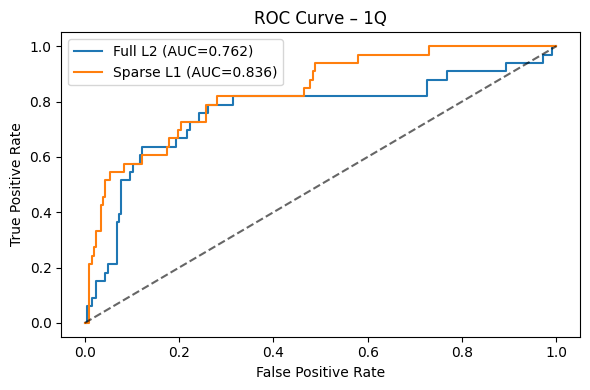

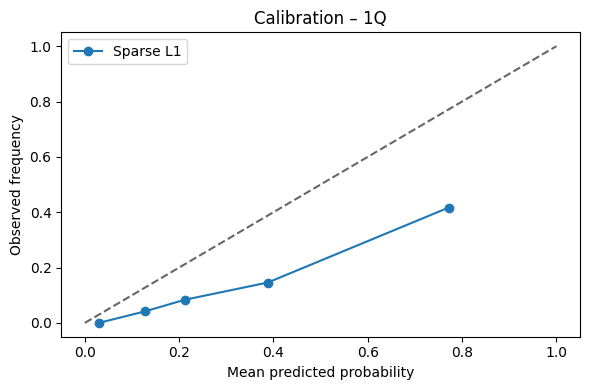

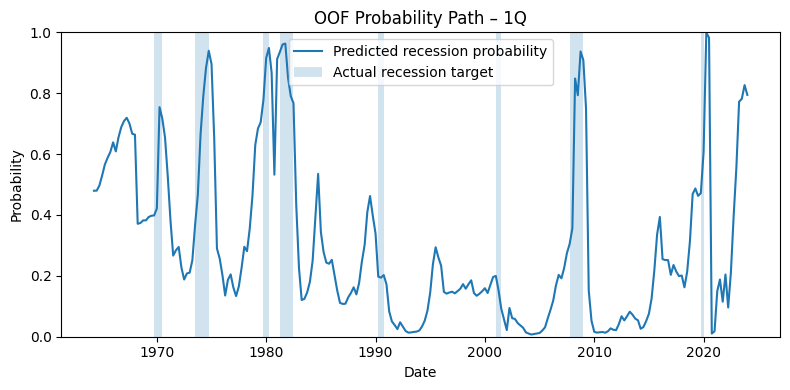

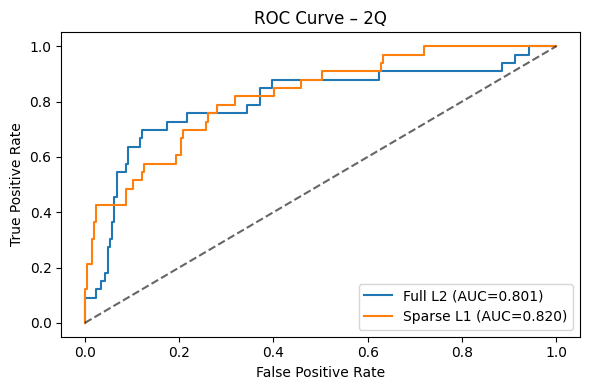

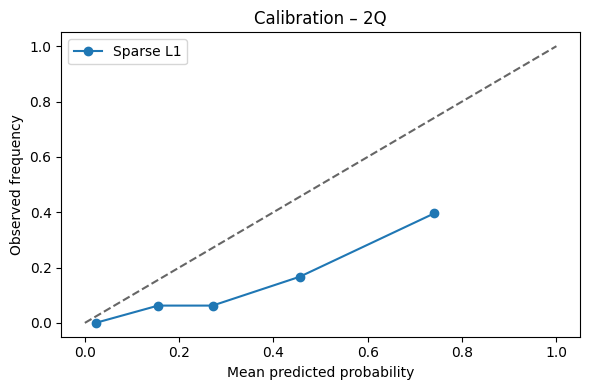

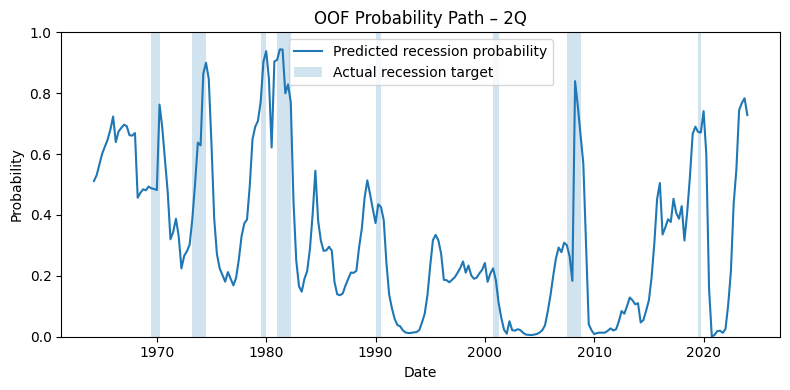

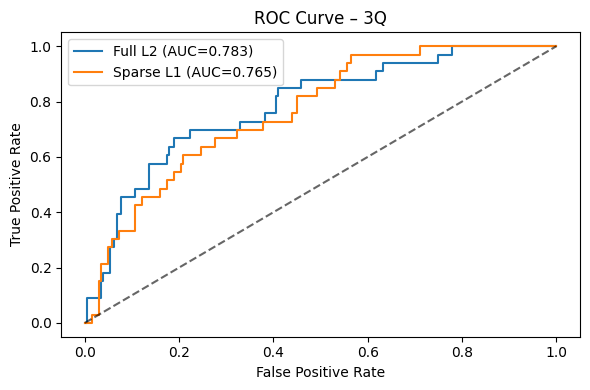

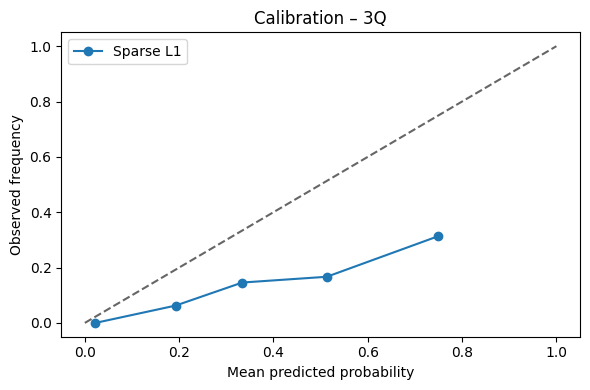

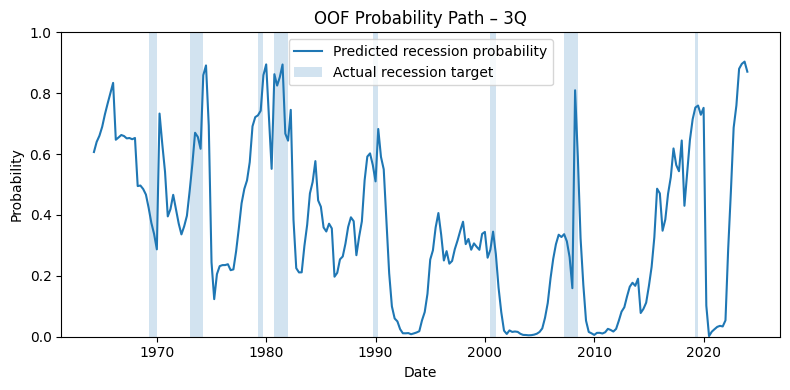

In [19]:
# c
for horizon in horizons:
    sparse = oof_store[(horizon, "sparse_l1")]
    full = oof_store[(horizon, "full_l2")]

    # ROC
    plt.figure(figsize=(6, 4))
    for name, frame in [("Full L2", full), ("Sparse L1", sparse)]:
        fpr, tpr, _ = roc_curve(frame["y_true"], frame["y_prob"])
        auc = roc_auc_score(frame["y_true"], frame["y_prob"])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_roc.png"), dpi=150)
    plt.show()

    # Calibration
    prob_true, prob_pred = calibration_curve(sparse["y_true"], sparse["y_prob"], n_bins=5, strategy="quantile")
    plt.figure(figsize=(6, 4))
    plt.plot(prob_pred, prob_true, marker="o", label="Sparse L1")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_calibration.png"), dpi=150)
    plt.show()

    # Predicted probability path
    plt.figure(figsize=(8, 4))
    plt.plot(sparse["Date"], sparse["y_prob"], label="Predicted recession probability")
    plt.fill_between(
        sparse["Date"], 0, 1,
        where=sparse["y_true"].astype(bool),
        alpha=0.2,
        transform=plt.gca().get_xaxis_transform(),
        label="Actual recession target"
    )
    plt.ylim(0, 1)
    plt.xlabel("Date")
    plt.ylabel("Probability")
    plt.title(f"OOF Probability Path – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_probability_timeseries.png"), dpi=150)
    plt.show()


## 3.5 - Mutual Information for Q1, Q2, Q3

In [20]:
# Show MI rankings
for horizon, table in mi_tables.items():
    print("\n", horizon)
    display(table.to_frame("mutual_information"))



 Target_1Q_ahead


,mutual_information
CPIAUCSL_roll6,0.198367
CPIAUCSL_lag3,0.192008
CPIAUCSL_lag2,0.176172
CPIAUCSL_roll3,0.174360
CPIAUCSL_lag1,0.173945
CPIAUCSL,0.162510
INDPRO_lag2,0.135303
FEDFUNDS_lag3,0.122408
INDPRO_roll3,0.120382
INDPRO_lag3,0.096497



 Target_2Q_ahead


,mutual_information
CPIAUCSL_roll6,0.205970
CPIAUCSL_lag2,0.195342
CPIAUCSL_roll3,0.187732
CPIAUCSL_lag1,0.178093
CPIAUCSL_lag3,0.177804
CPIAUCSL,0.177172
INDPRO_lag1,0.138079
INDPRO_roll3,0.126727
FEDFUNDS_lag2,0.116363
INDPRO_roll6,0.104302



 Target_3Q_ahead


,mutual_information
CPIAUCSL_roll6,0.207771
CPIAUCSL_roll3,0.202602
CPIAUCSL_lag1,0.196999
CPIAUCSL,0.182152
CPIAUCSL_lag3,0.181790
CPIAUCSL_lag2,0.180437
INDPRO,0.144936
FEDFUNDS_lag1,0.110540
INDPRO_lag1,0.102597
INDPRO_roll6,0.097733


In [21]:
# Show coefficient tables
for horizon, table in coef_tables.items():
    print("\n", horizon)
    display(table.head(10))



 Target_1Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
0,const,-3.626796,2.466365e-13,0.026601,0.010074,0.070243
3,INDPRO,-1.240705,3.319455e-03,0.289180,0.126335,0.661930
11,post_2008,1.464836,5.614181e-03,4.326835,1.534461,12.200707
1,T10Y2Y,1.689995,9.870438e-03,5.419454,1.501273,19.563717
12,post_2020,-1.279110,1.601442e-02,0.278285,0.098276,0.788008
4,BAA10Y,0.709105,2.608871e-02,2.032171,1.088103,3.795340
6,T10Y2Y_roll6,-2.614820,5.436281e-02,0.073181,0.005100,1.050187
9,FEDFUNDS_lag1,1.617207,5.477506e-02,5.038996,0.967444,26.245936
7,UNRATE_lag2,-2.604090,6.030890e-02,0.073970,0.004888,1.119508
2,UNRATE,0.663764,1.276634e-01,1.942089,0.826772,4.561973



 Target_2Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
2,BAA10Y,0.776199,0.001323,2.173196,1.353124,3.490277
8,post_2008,1.194868,0.004462,3.303121,1.449565,7.526816
4,T10Y2Y_lag3,-1.119391,0.005448,0.326479,0.148259,0.718935
1,INDPRO,-0.794354,0.018677,0.451873,0.233091,0.876007
5,UNRATE_lag1,-1.269537,0.256609,0.280962,0.031339,2.518919
3,FEDFUNDS,0.748848,0.300659,2.114563,0.512116,8.731179
7,FEDFUNDS_lag1,0.786019,0.301227,2.194642,0.494518,9.739694
6,UNRATE_lag2,-0.474450,0.676408,0.622227,0.067040,5.775148
0,const,-5.557535,0.999981,0.003858,0.000000,inf
9,post_2020,-8.935274,0.999991,0.000132,0.000000,inf



 Target_3Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
3,FEDFUNDS,1.546813,0.000008,4.696477e+00,2.380859e+00,9.264258e+00
4,T10Y2Y_lag3,-1.454051,0.001729,2.336220e-01,9.408072e-02,5.801320e-01
2,BAA10Y,1.202884,0.003099,3.329707e+00,1.500494e+00,7.388869e+00
9,post_2008,1.473851,0.005181,4.366018e+00,1.553525e+00,1.227023e+01
5,BAA10Y_lag3,-1.413693,0.028436,2.432433e-01,6.868764e-02,8.613970e-01
1,UNRATE,-1.497671,0.186458,2.236504e-01,2.424510e-02,2.063076e+00
7,CPIAUCSL_lag2,-42.505918,0.225893,3.466686e-19,4.602712e-49,2.611050e+11
8,CPIAUCSL_lag3,41.213028,0.238461,7.917546e+17,1.380667e-12,4.540381e+47
6,UNRATE_lag1,-0.124796,0.913584,8.826768e-01,9.266707e-02,8.407715e+00
0,const,-5.357751,0.999064,4.711490e-03,0.000000e+00,inf


## Notes for the report

- The **walk-forward evaluation** is the out-of-sample score you should report first.
- The **sparse L1 model** is usually the cleaner baseline for interpretation.
- The coefficient significance table is **descriptive**, because it is fit on the full sample after feature screening.
- For the presentation, the cleanest story is:
  - **1Q ahead** should perform best
  - **2Q ahead** should still be useful but weaker
  - **3Q ahead** should degrade as expected
  - yield-curve and financial-stress variables should dominate the leading signal
